In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.patches as patches
from scipy.io import loadmat
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.text import Text
plt.rcParams.update({"font.family": "Play",})

In [2]:
path = os.path.abspath(f'')

In [3]:
power = 370
scanspeed = 50

FEM = np.load(path+f"/MLDATA/TEMP/p{power}s{scanspeed}cTF0.npy")
# FEM = np.load("/home/bluebird/3_Codes/12_MultiPrincipalEA/2_Post_Processing/figures/comp_plot_data/TEMP.npy")[424]
PD = np.load(path+f"/PredData/Power/TEMP_pred_p{power}s{scanspeed}_Co0.35_Cr0.13_Fe0.15_full.npy")
TIME = np.load(path+f"/MLDATA/SIM_TIME/p{power}s{scanspeed}cTF0.npy")
FEM.shape, PD.shape, TIME.shape

((10, 260, 1000), (10, 260, 1000), (10,))

In [46]:
def plot_fig(np_data, time, data_from='FEM'):

    # laser_pos = np.argmax(np_data[0, :])
    # time_swept = ((laser_pos-125)/scanspeed) - 3
    laser_pos = 125 + (time-3)*(scanspeed*1e-2)
    
    fig, ax1 = plt.subplots(1, 1, figsize=[14, 8], frameon=True)
    ax1.set_facecolor((0, 0, 0, 0))
    
    cmap = plt.get_cmap('RdYlGn_r')
    cmap.set_under('white', alpha=0)
    hmap1 = ax1.imshow(np_data, cmap=cmap, aspect=1.0,  interpolation='quadric')
    
    ax1.arrow(laser_pos,-75, 0, 71,  width = 10, color='red', length_includes_head=True, clip_on=False)
    
    # ax1.set_title(f't = {time_swept:.0f}'+r'$\mathbf{\mu}$s', pad=10, loc='right', fontsize=25, weight='bold')
    ax1.set_title(f't = {(time)/1000:.2f}'+r' $\mathbf{ms}$', pad=10, loc='right', fontsize=25, weight='bold')
    
    contour_levels = [450, 700,  1100]
    contour = ax1.contour(np_data, levels=contour_levels, colors='k', linewidths=3, linestyles='dashdot')
    clabels = plt.clabel(contour, inline=True, fontsize=30, colors='k', fmt='%1.0f K')
    for label, color in zip(clabels, ['magenta', 'b', 'r']): label.set_fontweight('bold'); label.set_color(color)
    
    
    ############## Color Bar ###########
    ax2 = fig.add_axes([0.92, 0.315, 0.05, 0.355]) 
    ax2.tick_params(axis='both', labelcolor='black', labelsize=1, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    cbar = fig.colorbar(hmap1, cax=ax2, orientation='vertical')
    cbar.ax.tick_params(labelsize=25, direction='in', length=0)
    
    cbar.set_ticks([np.min(np_data)*1.5, (np.max(np_data)+300)/2, np.max(np_data)*0.96], labels=[f'{np.min(np_data):.0f}', f'{np.max(np_data)/2 :.0f}', f'{np.max(np_data)*1.0:.0f}'], weight='bold') 
    
    text = Text(x=0.935, y=0.335, text=r'$\mathbf{\leftarrow}$   T [K]  $\mathbf{\rightarrow}$', fontsize=28, color='k', rotation=90, weight='bold')
    fig.add_artist(text)
    
    ax1.set_ylim(260, -1)    
    ax1.set_xlim(-1,1001)
    ax1.tick_params(axis='both', labelcolor='black', labelsize=65, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
    
    ax1.spines[:].set_linewidth(2)
    ax2.spines[:].set_linewidth(2)

    plt.savefig(f"/home/bluebird/3_Codes/12_MultiPrincipalEA/2_Post_Processing/figures/{data_from}_Tdist.png", transparent=True, bbox_inches="tight", pad_inches=0.12)
    
    plt.show()

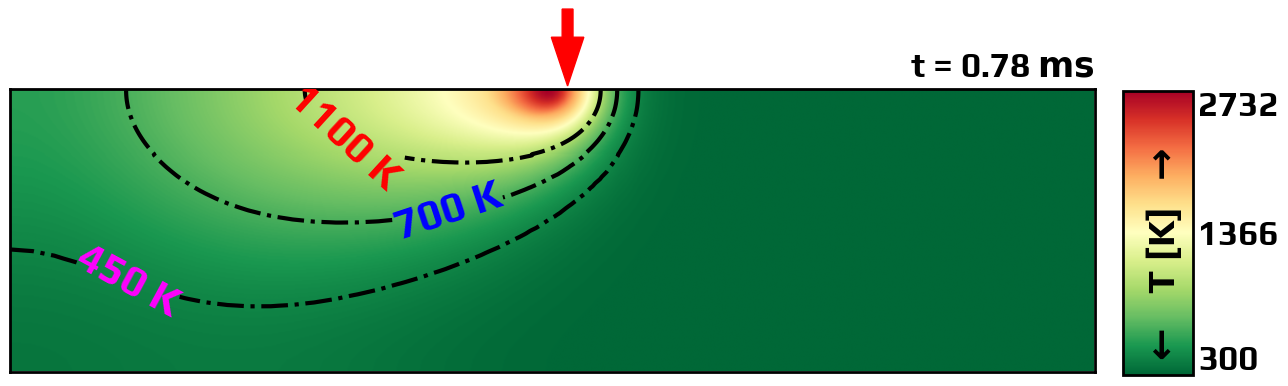

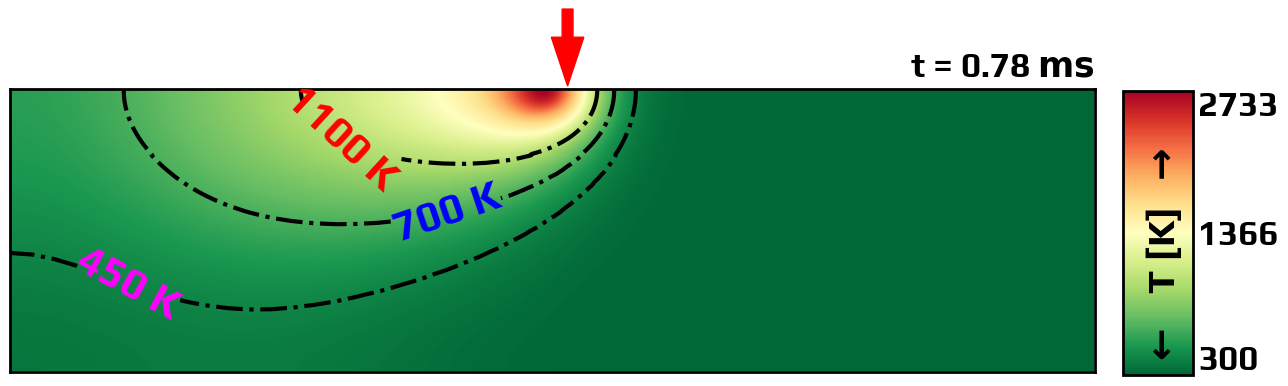

(None, None)

In [47]:
t_step = 5
plot_fig(FEM[t_step], time=TIME[t_step], data_from='FEM'), plot_fig(PD[t_step], time=TIME[t_step], data_from='ML')
# plot_fig(FEM, time=TIME[t_step], data_from='FEM'), plot_fig(PD[t_step], time=TIME[t_step], data_from='ML')

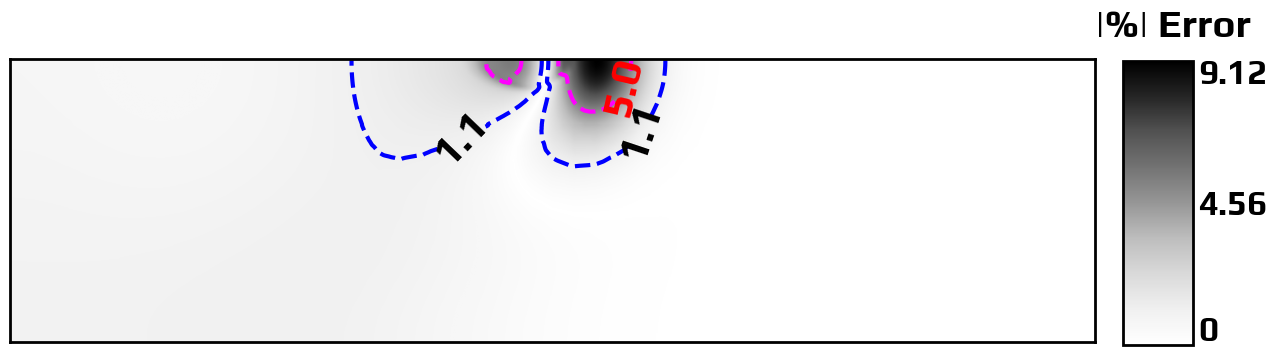

In [45]:
# FEM = np.load("/home/bluebird/3_Codes/12_MultiPrincipalEA/2_Post_Processing/figures/comp_plot_data/TEMP.npy")[424]
err = (np.abs(FEM - PD)/FEM)*100
t_step = 5
np_data = err[t_step]

time=TIME[t_step]
# laser_pos = np.argmax(np_data[0, :])
# time_swept = ((laser_pos-125)/scanspeed) - 3
laser_pos = 125 + (time-3)*(scanspeed*1e-2)

fig, ax1 = plt.subplots(1, 1, figsize=[14, 8], frameon=True)
ax1.set_facecolor((0, 0, 0, 0))
cmap = plt.get_cmap('Greys')
cmap.set_under('white', alpha=0)
hmap1 = ax1.imshow(np_data, cmap=cmap, aspect=1.0,  interpolation='quadric')
# ax1.arrow(laser_pos,-75, 0, 71,  width = 10, color='red', length_includes_head=True, clip_on=False)
# ax1.set_title(f't = {time_swept:.0f}'+r'$\mathbf{\mu}$s', pad=10, loc='right', fontsize=25, weight='bold')
# contour_levels = [0.015, 0.03,  0.06]
contour_levels = [1.1, 5.0]
contour = ax1.contour(np_data, levels=contour_levels, colors=['b','magenta','k'], linewidths=3, linestyles='--')
clabels = ax1.clabel(contour, inline=True, fontsize=30, colors=['b','magenta','k'], fmt='%0.1f')
for label, color in zip(clabels, ['k', 'k', 'r']): label.set_fontweight('bold'); label.set_color(color)

############## Color Bar ###########
ax2 = fig.add_axes([0.92, 0.315, 0.05, 0.355]) 
ax2.tick_params(axis='both', labelcolor='black', labelsize=1, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
cbar = fig.colorbar(hmap1, cax=ax2, orientation='vertical')
cbar.ax.tick_params(labelsize=25, direction='in', length=0)

cbar.set_ticks([0.5, (np.max(np_data))/2, np.max(np_data)*0.96], labels=[f'{np.min(np_data):.0f}', f'{np.max(np_data)/2 :.2f}', f'{np.max(np_data)*1.0:.2f}'], weight='bold') 

text = Text(x=0.9, y=0.7, text=r'|%| Error', fontsize=28, color='k', rotation=0, weight='bold')
fig.add_artist(text)

ax1.set_ylim(260, -1)    
ax1.set_xlim(-1,1001)
ax1.tick_params(axis='both', labelcolor='black', labelsize=65, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax1.spines[:].set_linewidth(2)
ax2.spines[:].set_linewidth(2)

plt.savefig(f"/home/bluebird/3_Codes/12_MultiPrincipalEA/2_Post_Processing/figures/Err_Tdist.png", transparent=True, bbox_inches="tight", pad_inches=0.12)

plt.show()

In [ ]:
'BuGn', 'Grays', 'Greys', 

In [145]:
cmaps = ['Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Grays_r', 'Greens', 
'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 
'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn',
'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 
'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'berlin', 'berlin_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 
'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 
'gist_grey', 'gist_grey_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 
'gist_yerg', 'gist_yerg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'grey', 'grey_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'inferno', 'inferno_r', 'jet', 
'jet_r', 'magma', 'magma_r', 'managua', 'managua_r', 'nipy_spectral', 'nipy_spectral_r', 'ocean', 'ocean_r', 'pink', 'pink_r', 'plasma', 'plasma_r', 'prism', 'prism_r', 'rainbow', 
'rainbow_r', 'seismic', 'seismic_r', 'spring', 'spring_r', 'summer', 'summer_r', 'tab10', 'tab10_r', 'tab20', 'tab20_r', 'tab20b', 'tab20b_r', 'tab20c', 'tab20c_r', 'terrain', 
'terrain_r', 'turbo', 'turbo_r', 'twilight', 'twilight_r', 'twilight_shifted', 'twilight_shifted_r', 'vanimo', 'vanimo_r', 'viridis', 'viridis_r', 'winter', 'winter_r']

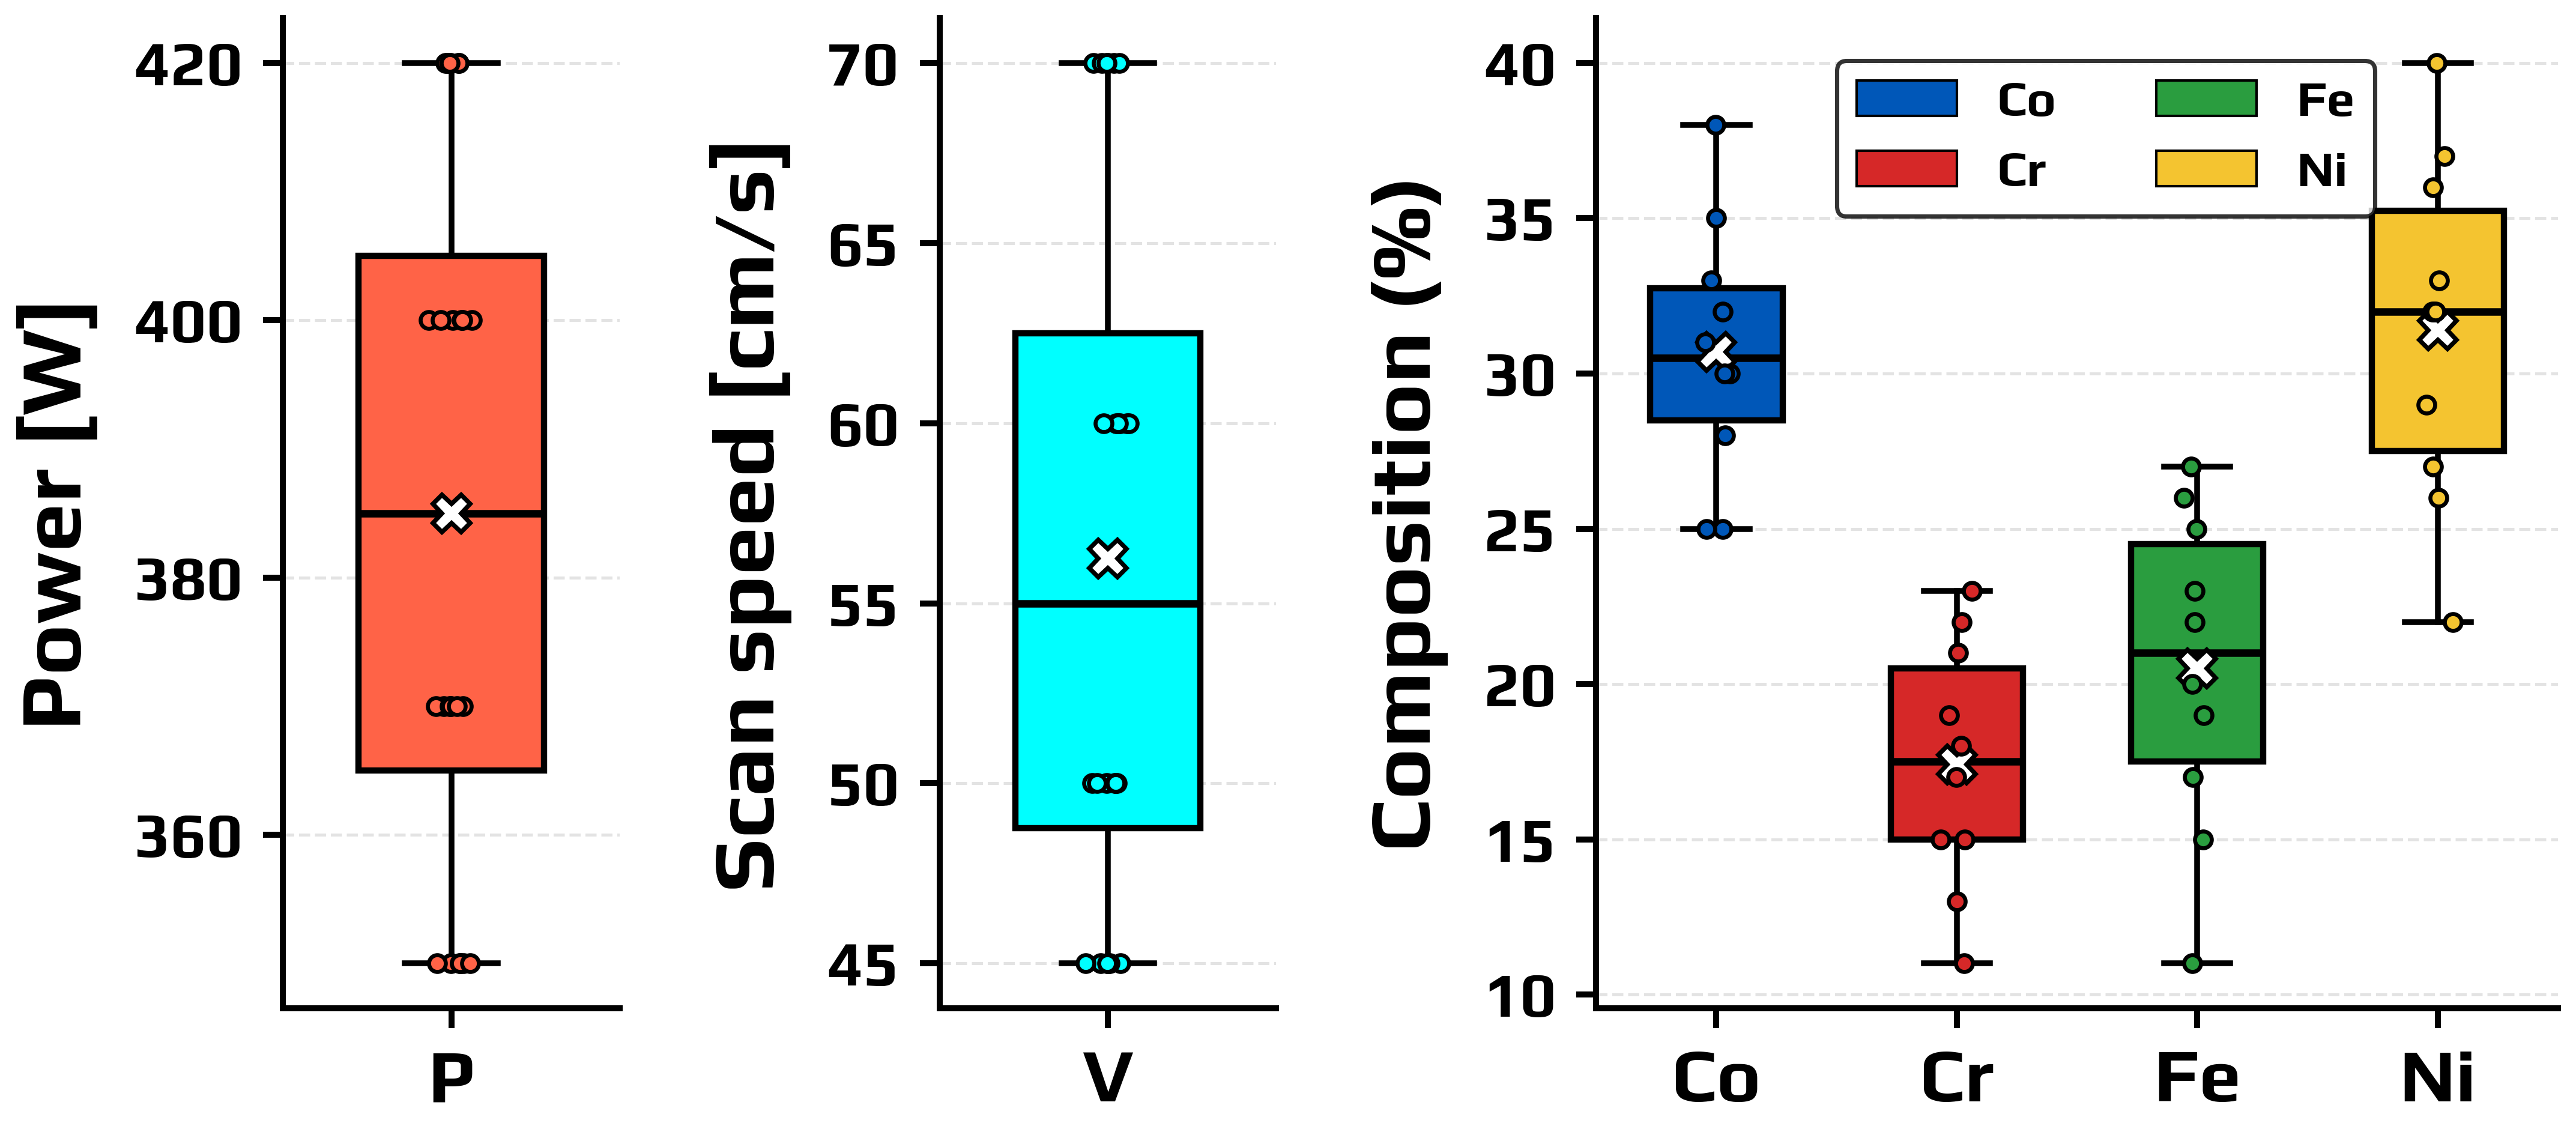

In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

training_df = pd.read_csv("Training_Data_Variables.csv")
ctf_df = pd.read_csv("nomenclature_phase_composition_thermodynamic_factor_tensor_components.csv")

power = training_df["P (W)"].dropna().values
scan_speed = training_df["v (cm/s)"].dropna().values

composition_cols = ["Co", "Cr", "Fe", "Ni"]
composition_data = [ctf_df[col].dropna().values for col in composition_cols]

composition_data = [x * 100 for x in composition_data]
composition_ylabel = "Composition (%)"

# ============================================================
# Global plot style
# ============================================================
plt.rcParams.update({
    "font.family": "Play",
    "font.size": 30,
    "axes.labelsize": 35,
    "axes.labelweight": "bold",
    "axes.titlesize": 24,
    "axes.titleweight": "bold",
    "xtick.labelsize": 30,
    "ytick.labelsize": 25,
    "legend.fontsize": 20,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 2.4,
})


def beautified_boxplot(ax, data, labels, colors, ylabel, title):
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55, showmeans=True, 
                    medianprops=dict(color="black", linewidth=3.0), meanprops=dict(marker="X", markerfacecolor="white", markeredgecolor="black", markersize=15, markeredgewidth=1.8),
                    whiskerprops=dict(color="black", linewidth=2.3), capprops=dict(color="black", linewidth=2.3),
                    flierprops=dict(marker="s", markerfacecolor="white", markeredgecolor="black", markersize=6.5, alpha=0.85))

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(2.5)
        patch.set_alpha(1.0)

    # Add lightly jittered raw data points
    rng = np.random.default_rng(12)
    for i, y in enumerate(data, start=1):
        x = rng.normal(i, 0.035, size=len(y))
        ax.scatter(x, y, s=45, color=colors[i - 1], edgecolor="black", linewidth=1.6, alpha=1.0, zorder=3)

    ax.set_ylabel(ylabel, fontweight="bold", labelpad=14)
    ax.set_title(title, fontweight="bold", pad=18)

    ax.grid(axis="y", linestyle="--", linewidth=1.2, alpha=0.35)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", direction="out", length=8, width=2.4, pad=8)

    for tick in ax.get_xticklabels(): tick.set_fontweight("bold")
    for tick in ax.get_yticklabels(): tick.set_fontweight("bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.4)
    ax.spines["bottom"].set_linewidth(2.4)


# ============================================================
# Figure with 3 subplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 7), gridspec_kw={"width_ratios": [0.7, 0.7, 2]})
fig.patch.set_alpha(0)

power_color = "tomato"
speed_color = "cyan"
composition_colors = ["#0057B8", "#D62828", "#2A9D3F", "#F4C430"]

beautified_boxplot(ax=axes[0], data=[power], labels=["P"], colors=[power_color], ylabel="Power [W]", title="")
beautified_boxplot(ax=axes[1], data=[scan_speed], labels=["V"], colors=[speed_color], ylabel="Scan speed [cm/s]", title="")
beautified_boxplot(ax=axes[2], data=composition_data, labels=composition_cols, colors=composition_colors, ylabel=composition_ylabel, title="")

axes[2].legend(handles=[Patch(facecolor=c, edgecolor="black", label=l) for c, l in zip(composition_colors, composition_cols)], loc=(0.25,0.8), frameon=True, fancybox=True, edgecolor="black", ncol=2)

for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.get_frame().set_linewidth(1.7)
        for text in leg.get_texts():
            text.set_fontweight("bold")

plt.tight_layout(w_pad=1.20)

plt.savefig("/home/bluebird/3_Codes/12_MultiPrincipalEA/2_Post_Processing/figures/Boxplots.png", transparent=True, bbox_inches="tight", pad_inches=0.12)

plt.show()